![Ravine Image](https://drive.google.com/uc?id=1u-XFX-BEIWOWFtD0AdlXWoEK7kxdS5Q9)

$$f(w_0, w_1) = 0.5 \cdot (0.1 w_0^2 + 2.0 w_1^2)$$

* $w_0$ is the **shallow axis** (slope is gentle; requires large steps).
* $w_1$ is the **steep axis** (slope is $20\times$ steeper; prone to wild oscillations).
* The global minimum is at $(w_0, w_1) = (0.0, 0.0)$.

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Fix random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [ ]:
def ravine_loss(w):
    return 0.5 * (0.1 * w[0]**2 + 2.0 * w[1]**2)

In [ ]:
def track_optimizer(optimizer_cls, opt_kwargs, start_pos=[-4.5, 4.0], steps=50):
    # Create the parameter to optimize
    w = torch.tensor(start_pos, dtype=torch.float32, requires_grad=True)

    # Initialize PyTorch optimizer
    optimizer = optimizer_cls([w], **opt_kwargs)

    trajectory = [w.detach().clone().numpy()]
    loss_history = []

    for _ in range(steps):
        optimizer.zero_grad()
        loss = ravine_loss(w)
        loss.backward()
        optimizer.step()

        trajectory.append(w.detach().clone().numpy())
        loss_history.append(loss.item())

    return np.array(trajectory), loss_history

In [ ]:
def plot_trajectories(trajectories, title):
    x = np.linspace(-5.0, 5.0, 300)
    y = np.linspace(-5.0, 5.0, 300)
    X, Y = np.meshgrid(x, y)
    Z = 0.5 * (0.1 * X**2 + 2.0 * Y**2)

    plt.figure(figsize=(9, 6))
    plt.contour(X, Y, Z, levels=35, cmap="Blues_r", alpha=0.6)

    for name, traj in trajectories.items():
        plt.plot(traj[:, 0], traj[:, 1], marker="o", markersize=3, label=name, lw=2)

    plt.scatter([0], [0], color="red", marker="*", s=250, label="Global Minimum (0,0)", zorder=10)
    plt.title(title, fontsize=13, fontweight='bold')
    plt.xlabel("$w_0$ (Gentle Axis)", fontsize=11)
    plt.ylabel("$w_1$ (Steep Axis)", fontsize=11)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

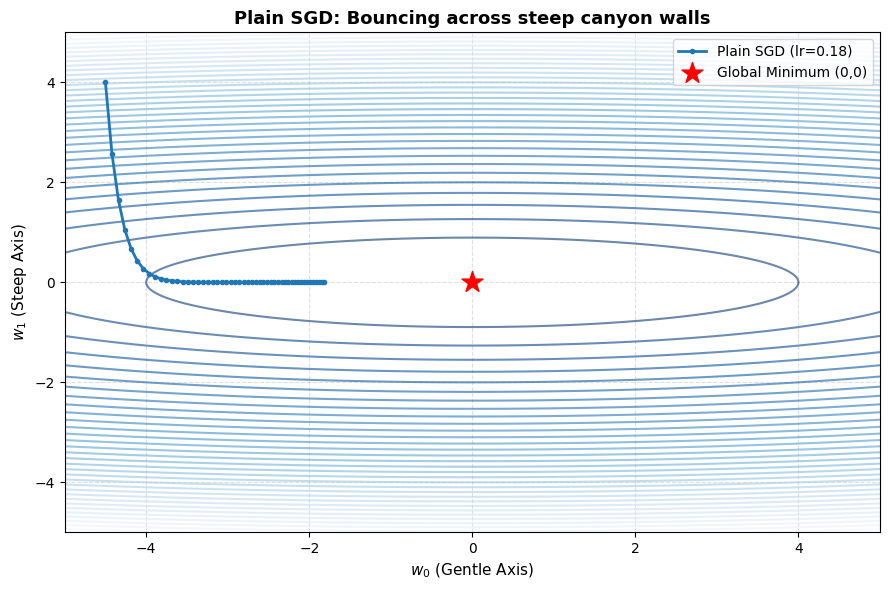

In [ ]:
sgd_traj, sgd_loss = track_optimizer(torch.optim.SGD, {'lr': 0.18})

plot_trajectories({"Plain SGD (lr=0.18)": sgd_traj}, "Plain SGD: Bouncing across steep canyon walls")

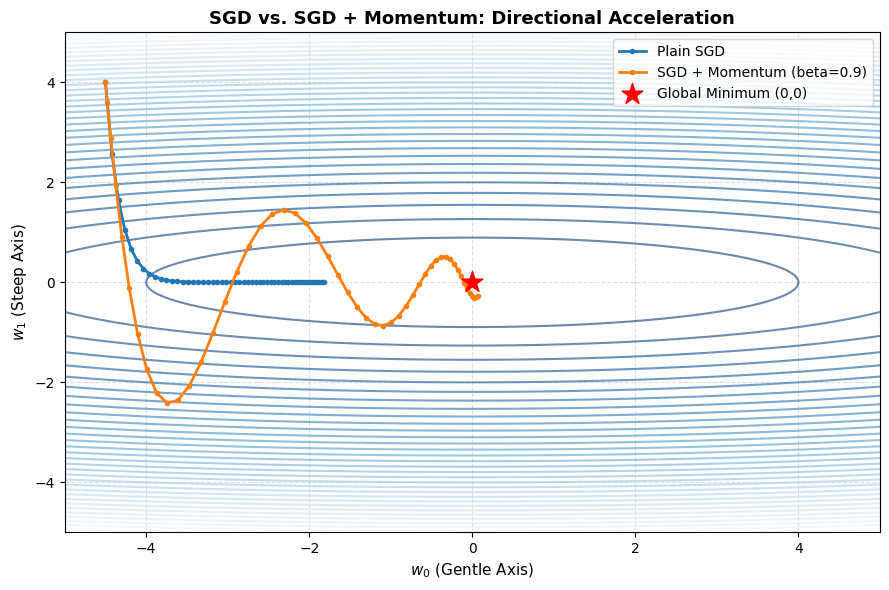

In [ ]:
momentum_traj, momentum_loss = track_optimizer(torch.optim.SGD, {'lr': 0.05, 'momentum': 0.9})

plot_trajectories({
    "Plain SGD": sgd_traj,
    "SGD + Momentum (beta=0.9)": momentum_traj
}, "SGD vs. SGD + Momentum: Directional Acceleration")

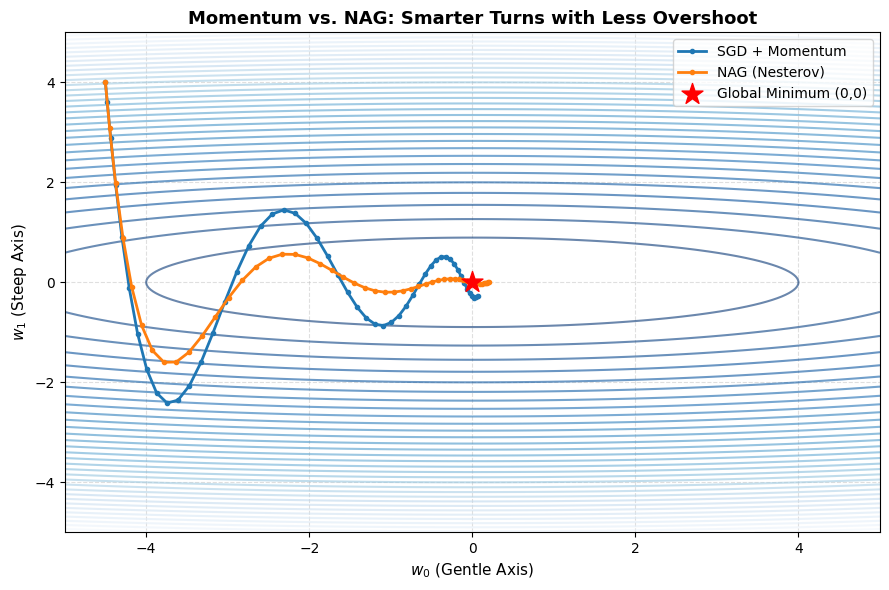

In [ ]:
nag_traj, nag_loss = track_optimizer(torch.optim.SGD, {'lr': 0.06, 'momentum': 0.9, 'nesterov': True})

plot_trajectories({
    "SGD + Momentum": momentum_traj,
    "NAG (Nesterov)": nag_traj
}, "Momentum vs. NAG: Smarter Turns with Less Overshoot")

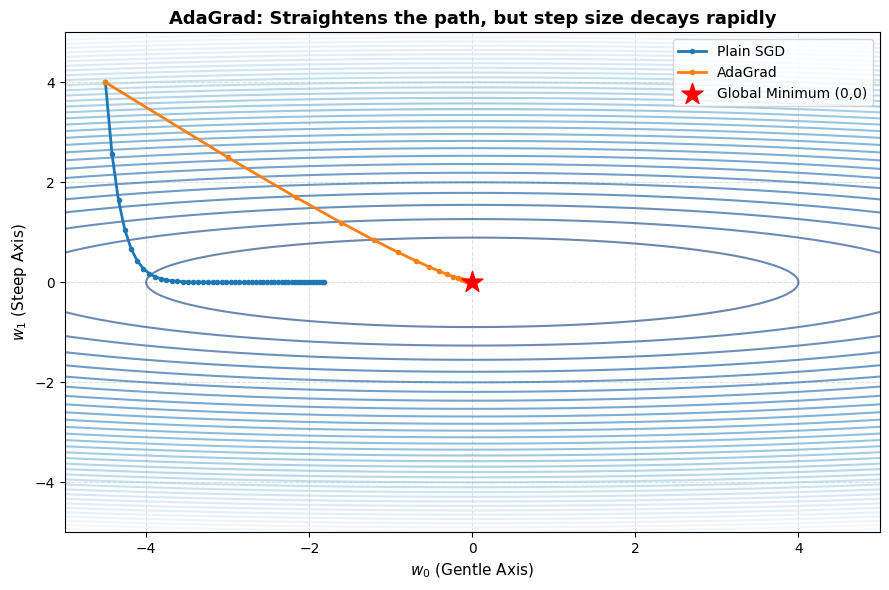

In [ ]:
adagrad_traj, adagrad_loss = track_optimizer(torch.optim.Adagrad, {'lr': 1.5})

plot_trajectories({
    "Plain SGD": sgd_traj,
    "AdaGrad": adagrad_traj
}, "AdaGrad: Straightens the path, but step size decays rapidly")

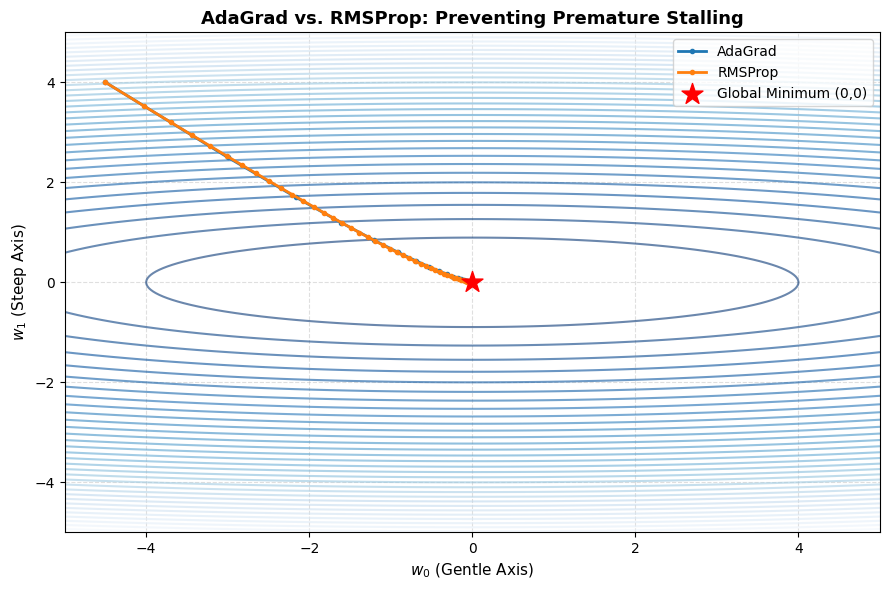

In [ ]:
rmsprop_traj, rmsprop_loss = track_optimizer(torch.optim.RMSprop, {'lr': 0.15, 'alpha': 0.9})

plot_trajectories({
    "AdaGrad": adagrad_traj,
    "RMSProp": rmsprop_traj
}, "AdaGrad vs. RMSProp: Preventing Premature Stalling")

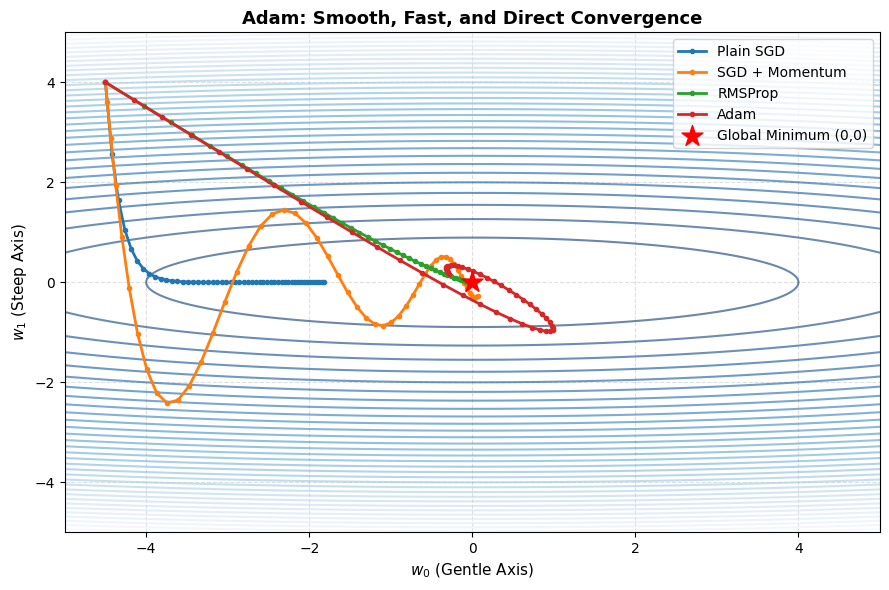

In [ ]:
adam_traj, adam_loss = track_optimizer(torch.optim.Adam, {'lr': 0.35, 'betas': (0.9, 0.999)})

plot_trajectories({
    "Plain SGD": sgd_traj,
    "SGD + Momentum": momentum_traj,
    "RMSProp": rmsprop_traj,
    "Adam": adam_traj
}, "Adam: Smooth, Fast, and Direct Convergence")

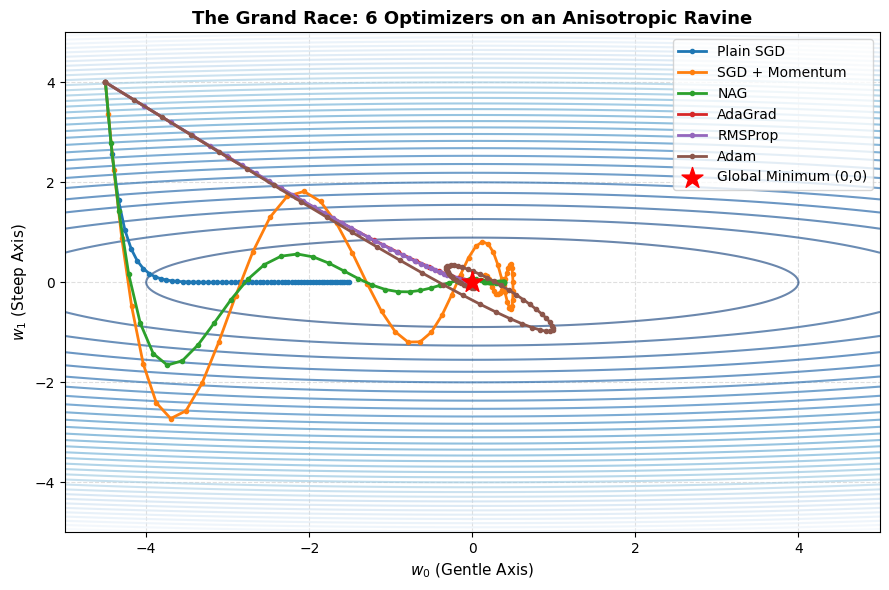

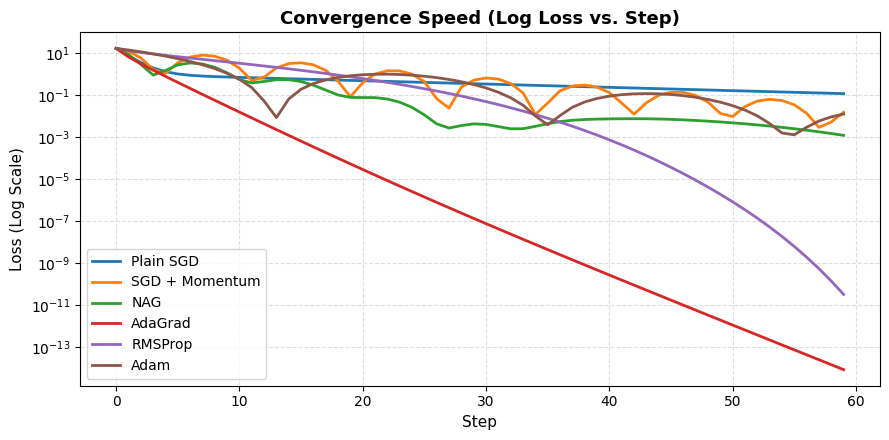

In [ ]:
optimizers_config = {
    "Plain SGD": (torch.optim.SGD, {'lr': 0.18}),
    "SGD + Momentum": (torch.optim.SGD, {'lr': 0.08, 'momentum': 0.9}),
    "NAG": (torch.optim.SGD, {'lr': 0.08, 'momentum': 0.9, 'nesterov': True}),
    "AdaGrad": (torch.optim.Adagrad, {'lr': 1.5}),
    "RMSProp": (torch.optim.RMSprop, {'lr': 0.15, 'alpha': 0.9}),
    "Adam": (torch.optim.Adam, {'lr': 0.35, 'betas': (0.9, 0.999)})
}

all_trajectories = {}
all_losses = {}

for name, (opt_cls, kwargs) in optimizers_config.items():
    traj, loss = track_optimizer(opt_cls, kwargs, steps=60)
    all_trajectories[name] = traj
    all_losses[name] = loss

# 1. Trajectory Plot
plot_trajectories(all_trajectories, "The Grand Race: 6 Optimizers on an Anisotropic Ravine")

# 2. Loss Convergence Curves
plt.figure(figsize=(9, 4.5))
for name, loss_hist in all_losses.items():
    plt.plot(loss_hist, label=name, lw=2)

plt.yscale('log')
plt.title("Convergence Speed (Log Loss vs. Step)", fontsize=13, fontweight='bold')
plt.xlabel("Step", fontsize=11)
plt.ylabel("Loss (Log Scale)", fontsize=11)
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()